In [13]:
# Import required libraries
import pandas as pd
import numpy as np
import json
import ast
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [14]:
# Step 1: Load the Dataset with Labels (Overall Score as Target)
df = pd.read_csv('../../data/test-final/master_dataset_for_training.csv')
print("Dataset loaded. Total records:", len(df))

Dataset loaded. Total records: 301


In [15]:
def parse_feature_vector(feature_str):
    if not isinstance(feature_str, str):
        try:
            return np.array(feature_str, dtype=float)
        except Exception as e:
            print("Error converting non-string to array:", e)
            return np.zeros(1)
    
    cleaned_str = feature_str.replace('\n', ' ').strip()
    
    if not (cleaned_str.startswith('[') and cleaned_str.endswith(']')):
        print("Invalid format (missing brackets):", cleaned_str)
        return np.zeros(1)
    
    # If commas are present, try JSON or ast.literal_eval first
    if ',' in cleaned_str:
        fixed_str = cleaned_str.replace("'", '"')
        try:
            vec = json.loads(fixed_str)
            return np.array(vec, dtype=float)
        except Exception as e_json:
            print("JSON parsing error:", e_json)
        
        try:
            vec = ast.literal_eval(cleaned_str)
            return np.array(vec, dtype=float)
        except Exception as e_ast:
            print("ast.literal_eval error:", e_ast)
    
    # Fallback: assume values are whitespace-separated
    try:
        inner_str = cleaned_str[1:-1].strip()
        parts = inner_str.split()
        vec = [float(part) for part in parts]
        return np.array(vec, dtype=float)
    except Exception as e_manual:
        print("Manual fix error:", e_manual)
        return np.zeros(1)

# Apply parsing to each row
df['structured_features_parsed'] = df['structured_features'].apply(parse_feature_vector)

In [16]:
example_vector = df['structured_features_parsed'].iloc[0]
print("Example structured feature vector:", example_vector)
print("Shape of example vector:", example_vector.shape)


Example structured feature vector: [1. 1. 1. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.
 1. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Shape of example vector: (42,)


In [17]:
# Step 3: Build the Feature Matrix X and Target Vector y
# Stack all the parsed structured feature vectors into a 2D NumPy array
X = np.vstack(df['structured_features_parsed'].values)
print("Feature matrix shape:", X.shape)

Feature matrix shape: (301, 42)


In [18]:
# The target variable is the final overall score (Overall_Score)
# Make sure it is numeric
y = df['Overall_Score'].astype(float).values
print("Target vector shape:", y.shape)


Target vector shape: (301,)


In [19]:
# Step 4: Split the Dataset into Training and Test Sets
# We'll use a 70/30 split.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (210, 42)
Test set shape: (91, 42)


In [20]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained.")


Model trained.


In [21]:
# Step 6: Predict on Training and Test Sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [22]:
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

In [23]:
print("Baseline Linear Regression Performance:")
print(f"Train RMSE: {train_rmse:.3f}, Train R²: {train_r2:.3f}")
print(f"Test RMSE: {test_rmse:.3f}, Test R²: {test_r2:.3f}")

Baseline Linear Regression Performance:
Train RMSE: 0.078, Train R²: 0.871
Test RMSE: 0.070, Test R²: 0.876


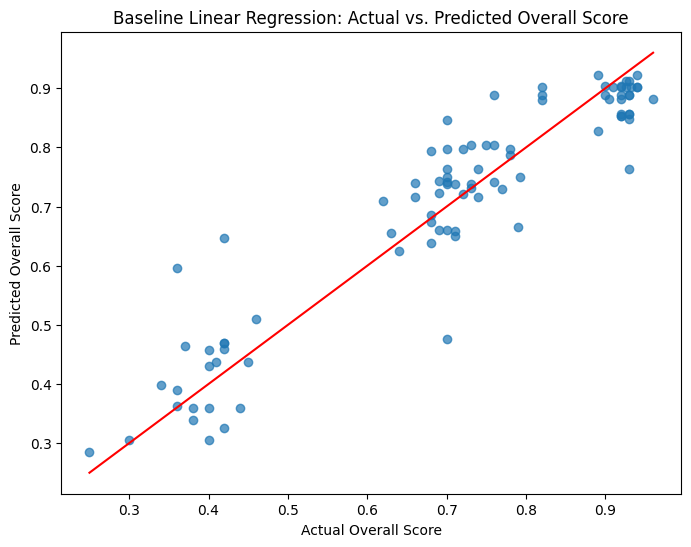

In [24]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.7)
plt.xlabel("Actual Overall Score")
plt.ylabel("Predicted Overall Score")
plt.title("Baseline Linear Regression: Actual vs. Predicted Overall Score")
# Plot a diagonal reference line
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.show()